# Agentic Signal versus Background Classification for Exotic Higgs Decays

This tutorial uses a collider-physics binary classification problem. The goal is to distinguish an exotic-Higgs signal from Standard Model heavy-flavour background.

| Signal process | Background process |
|---|---|
| $pp \to H$ | $pp \to \mathrm{QCD\ heavy\ flavour}$ |
| $H \to aa$ | examples: $b\bar{b}j$, $b\bar{b}jj$, $b\bar{b}b\bar{b}$ |
| $a \to b\bar{b}$ and $a \to b\bar{b}$ | multijet final states with heavy-flavour jets |
| final state: $b\bar{b}b\bar{b}$ | final state: jets that can mimic four-b signal events |

| Signal Feynman-diagram sketch | Background Feynman-diagram sketch |
|---|---|
| $pp \to H \to aa \to (b\bar{b})(b\bar{b})$ | $pp \to \mathrm{QCD} \to b\bar{b}+\mathrm{jets}$ |

The machine-learning task is binary classification:

- `label = 1`: exotic-Higgs signal.
- `label = 0`: QCD heavy-flavour background.

The physics objective is to identify events that are more signal-like than background-like, then check whether applying a classifier threshold improves a simple counting sensitivity. The workflow uses `Avencast/EveNet-ExoticHiggs-H2a4b`, associated with arXiv:2601.17126 and released with an MIT license. Only a small number of Parquet files are downloaded; the full dataset is not required.


## Section 1 - Setup Data

The helper `load_physics_pipeline` handles the low-level parsing of the EveNet Parquet file and returns a compact pandas dataframe called `selected_events`. The dataframe is arranged so the physics objects have consistent names:

- `label`: signal/background class label.
- `jet1`, `jet2`, `jet3`, `jet4`: the four leading jets ordered by transverse momentum.
- `pt`: transverse momentum, the momentum perpendicular to the proton beam.
- `eta`: pseudorapidity, a coordinate related to the jet direction along the beam axis.
- `phi`: azimuthal angle around the beam axis.
- `mass`: reconstructed jet mass.
- `btag`: b-tag information used to identify jets likely produced by bottom quarks.

The initial plots below show the cleaned four-jet sample before any agent modifies features or classifiers.

Infrastructure note: helper functions hide low-level file parsing and LLM response validation. Model training code is intentionally visible in the notebook through one `ClassificationAgent` class with a small model library.

Visible helper contracts:

| Helper | Input | Output |
| --- | --- | --- |
| `load_physics_pipeline(...)` | number of files, event cap, random seed | dictionary containing `selected_events`, cut-flow tables, and schema summaries |
| `request_strategy_from_cerebras(...)` | prompt, history, dataset summary, baseline summary, agent catalog | validated strategy dictionary |
| `summarize_planning_round(...)` | round number, plan, classifier agent, best threshold result | compact round summary for the next planning prompt |


In [60]:
%matplotlib inline

import json
import sys
from pathlib import Path

from time import sleep

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Classification models and metrics
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/PHYS417neuralNets

# Use paths relative to the notebook location so this folder can be copied elsewhere.
# Add the notebook folder to sys.path so helper modules can be imported from either the root folder or lab7/
notebook_dir = Path.cwd()
if not (notebook_dir / "agentic_lab7").exists() and (notebook_dir / "lab7" / "agentic_lab7").exists():
    notebook_dir = notebook_dir / "lab7"
if str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))

from agentic_lab7.api_key import CEREBRAS_API_KEY, CEREBRAS_MODEL
from agentic_lab7.pipeline_setup import load_physics_pipeline
from agentic_lab7.planning_tools import request_strategy_from_cerebras, summarize_round as summarize_planning_round

# Initialize numpy and pytorch random seeds for reproducibility
RANDOM_STATE = 123
MAX_EVENTS = 200_000
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
plt.rcParams["figure.figsize"] = (7, 5)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/.shortcut-targets-by-id/1M94wx0TfIQWCoDJLSJRl84SRZ0gYt-W7/PHYS417neuralNets


,raw_events_loaded,selected_events,columns
0,200000,75126,21


,label,jet1_pt,jet1_eta,jet1_phi,jet1_mass,jet1_btag,jet2_pt,jet2_eta,jet2_phi,jet2_mass,...,jet3_pt,jet3_eta,jet3_phi,jet3_mass,jet3_btag,jet4_pt,jet4_eta,jet4_phi,jet4_mass,jet4_btag
0,1.0,93.664531,-0.087359,-2.475345,9.789335,1.0,80.338509,1.576945,0.333819,0.000000,...,34.622795,0.511399,-2.549871,5.108600,1.0,32.414450,0.552133,2.214729,2.505994,1.0
1,1.0,61.916652,0.902399,0.266193,0.000000,0.0,47.088154,0.198319,2.316577,8.675580,...,46.221401,0.692270,-2.392012,1.113719,1.0,37.838821,0.947641,2.469884,0.000000,1.0
2,1.0,67.839815,-0.506841,-1.267455,8.586977,1.0,62.954586,-2.280551,-0.061890,0.000000,...,50.028944,-2.729800,1.251373,0.000000,1.0,44.099123,-3.184988,-2.491740,0.000000,1.0
3,0.0,52.155311,0.724185,1.833906,1.579675,1.0,46.139782,-2.184562,-1.162588,0.000000,...,39.789092,-0.756486,0.927674,2.875871,1.0,38.916300,-0.945284,-1.449909,6.906621,0.0
4,0.0,73.618286,0.643026,1.586173,5.096674,1.0,70.661523,-0.555229,-2.147839,10.997287,...,67.678974,0.281106,-2.774277,9.377133,1.0,60.258595,-1.421532,0.500439,0.000000,1.0


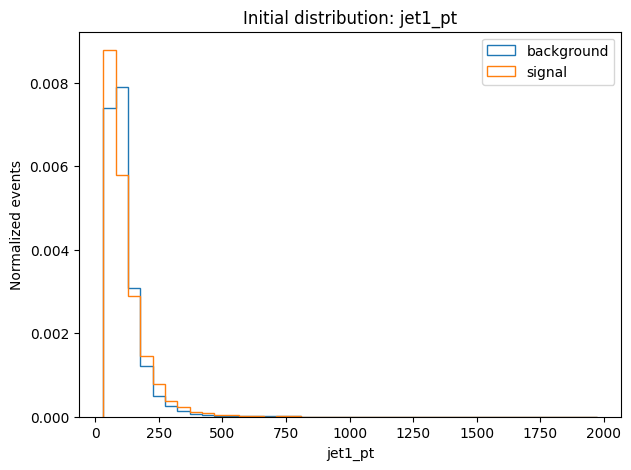

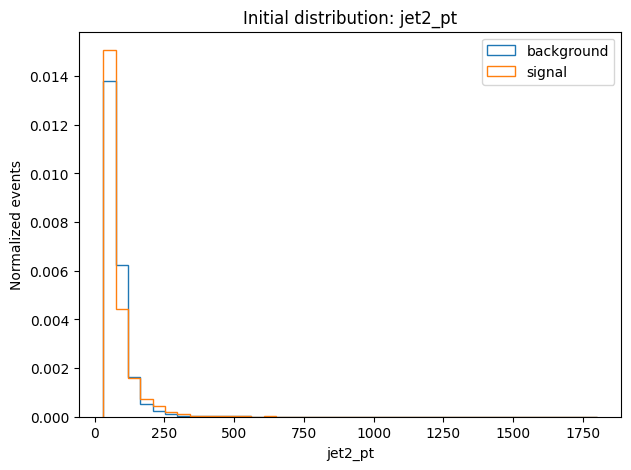

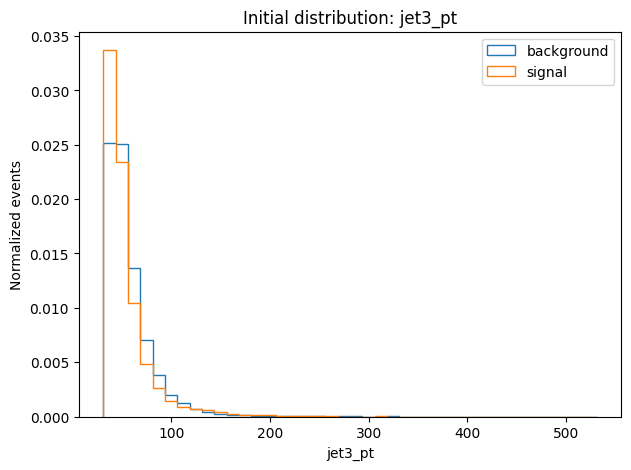

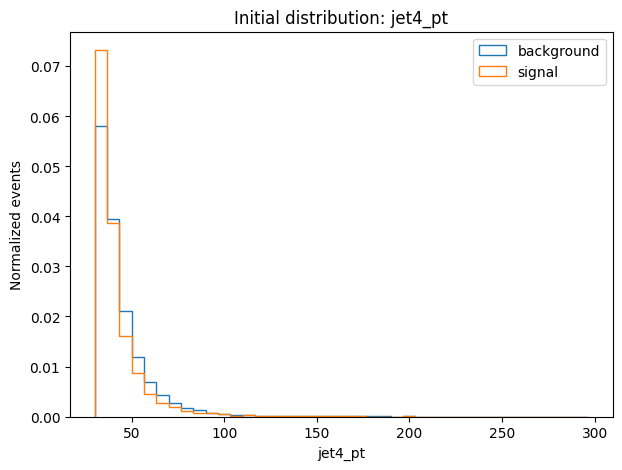

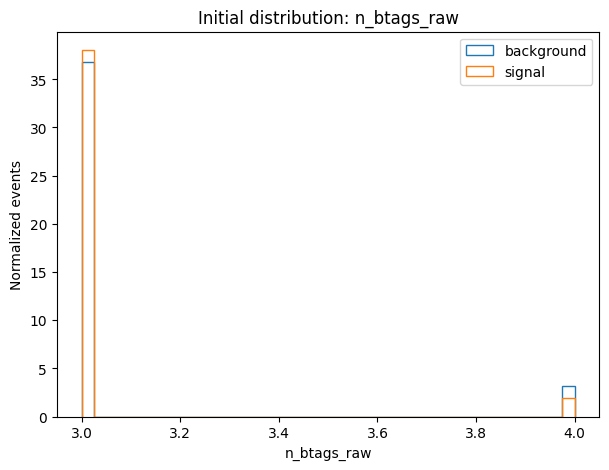

In [61]:
N_FILES_TO_USE = 24
pipeline = load_physics_pipeline(
    n_files_to_use=N_FILES_TO_USE,
    max_events=MAX_EVENTS,
    random_state=RANDOM_STATE,
)

selected_events = pipeline["selected_events"]

display(pd.DataFrame({
    "raw_events_loaded": [len(pipeline["data"])],
    "selected_events": [len(selected_events)],
    "columns": [selected_events.shape[1]],
}))
display(selected_events.head())

selected_events["n_btags_raw"] = selected_events[[f"jet{i}_btag" for i in range(1, 5)]].sum(axis=1)
plot_columns = ["jet1_pt", "jet2_pt", "jet3_pt", "jet4_pt", "n_btags_raw"]
for column in plot_columns:
    values = selected_events[column].dropna().to_numpy()
    bins = np.histogram_bin_edges(values, bins=40)
    plt.figure()
    for label, name in [(0, "background"), (1, "signal")]:
        class_values = selected_events.loc[selected_events["label"] == label, column].dropna().to_numpy()
        plt.hist(class_values, bins=bins, histtype="step", density=True, label=name)
    plt.xlabel(column)
    plt.ylabel("Normalized events")
    plt.title(f"Initial distribution: {column}")
    plt.legend()
    plt.show()


## Section 2 - Feature Agent Template Class

The feature agent transforms the cleaned event dataframe into an ML-ready feature matrix. It keeps the direct four-jet measurements and adds derived physics variables that summarize the event topology.

Direct per-jet features:

- `jetN_pt`: transverse momentum of jet `N`.
- `jetN_eta`: pseudorapidity of jet `N`.
- `jetN_phi`: azimuthal angle of jet `N`.
- `jetN_mass`: reconstructed mass of jet `N`.
- `jetN_btag`: b-tag value for jet `N`; the code counts a jet as tagged when this value is at least 0.5.

Derived event features:

- `ht`: scalar sum of the four jet transverse momenta, $p_{T,1}+p_{T,2}+p_{T,3}+p_{T,4}$.
- `m_4j`: invariant mass of the four-jet system.
- `m_jj_12`, ..., `m_jj_34`: invariant masses of all six jet pairs.
- `deltaR_jj_12`, ..., `deltaR_jj_34`: angular separations between jet pairs, using $\Delta R = \sqrt{(\Delta\eta)^2 + (\Delta\phi)^2}$ with $\Delta\phi$ wrapped into $[-\pi, \pi]$.
- `min_deltaR_jj`: smallest pairwise jet separation in the event.
- `mean_deltaR_jj`: average pairwise jet separation in the event.
- `n_btags`: number of the four leading jets passing the b-tag threshold.

These variables encode the signal hypothesis. In $H 	o aa 	o bar{b}bar{b}$, the final state contains four b quarks, often organized into two pairs from the intermediate particles `a`. QCD background can also contain b jets, but its pair masses, angular structure, total activity, and b-tag multiplicity do not have to follow the same pattern.

In [62]:
# Fill in the feature construction inside FeatureAgent.
class FeatureAgent:
    def __init__(self, name="four_jet_feature_agent"):
        self.name = name
        self.X = None
        self.y = None

    @staticmethod
    # Compute angular separation between jets i and j using eta difference and wrapped phi difference.
    def delta_phi(phi1, phi2):
        dphi = phi1-phi2
        return (dphi + np.pi) % (2 * np.pi) - np.pi

    @staticmethod
    def four_vector(df, jet):
        pt = df[f"jet{jet}_pt"].astype(float)
        eta = df[f"jet{jet}_eta"].astype(float)
        phi = df[f"jet{jet}_phi"].astype(float)
        mass = df[f"jet{jet}_mass"].astype(float)

        # Calculate feature values
        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)
        energy = np.sqrt(mass**2 + (pt**2 * np.cosh(eta)**2))

        return pd.DataFrame({"E": energy, "px": px, "py": py, "pz": pz}, index=df.index)

    @staticmethod
    # Invariant Mass (m_4j) = sqrt(E^2 - |p|^2)
    def invariant_mass(vectors):
        E = vectors["E"].sum(axis=1)
        px = vectors["px"].sum(axis=1)
        py = vectors["py"].sum(axis=1)
        pz = vectors["pz"].sum(axis=1)
        m2 = E**2 - px**2 - py**2 - pz**2
        return np.sqrt(np.clip(m2, 0, None))

    # Angular seperation is sqrt(delta_eta^2 + delta_phi^2)
    def delta_r(self, df, i, j):
        eta1, eta2 = df[f'jet{i}_eta'].values, df[f'jet{j}_eta'].values
        phi1, phi2 = df[f'jet{i}_phi'].values, df[f'jet{j}_phi'].values
        deta = eta1 - eta2
        dphi = phi1 - phi2
        # Handle phi periodicity wrapping [-pi, pi]
        dphi = np.remainder(dphi + np.pi, 2 * np.pi) - np.pi
        return np.sqrt(deta**2 + dphi**2)

    def features(self, selected_events):
        df = selected_events.copy()
        X = pd.DataFrame(index=df.index)

        # Direct jet features: these are ready to use.
        for jet in range(1, 5):
            for field in ["pt", "eta", "phi", "mass", "btag"]:
                X[f"jet{jet}_{field}"] = df[f"jet{jet}_{field}"].astype(float)

        vectors = {jet: self.four_vector(df, jet) for jet in range(1, 5)}

        # ht is sum of transvere momenta (pt)
        X["ht"] = X[[f"jet{i}_pt" for i in range(1, 5)]].sum(axis=1)

        # Invariant mass
        X["m_4j"] = self.invariant_mass(pd.concat(vectors.values(), axis=1))

        delta_r_values = []
        for i in range(1, 5):
            for j in range(i + 1, 5):
                # Calculate the invariant mass and the angular separation for each pair
                X[f"m_jj_{i}{j}"] = self.invariant_mass(pd.concat([vectors[i], vectors[j]], axis=1))
                X[f"deltaR_jj_{i}{j}"] = self.delta_r(df, i, j)

                delta_r_values.append(X[f"deltaR_jj_{i}{j}"])

        delta_r_table = pd.concat(delta_r_values, axis=1)

        # Min invariant mass
        X["min_deltaR_jj"] = delta_r_table.min(axis=1)

        # Mean invariant mass
        X["mean_deltaR_jj"] = delta_r_table.mean(axis=1)

        # Count btags
        X["n_btags"] = (df[[f"jet{i}_btag" for i in range(1, 5)]] >= 0.5).sum(axis=1)

        # Label column
        y = df["label"].astype(int)
        assert np.isfinite(X.to_numpy()).all(), "Feature matrix contains NaN or infinite values. Finish the feature TODOs."
        self.X = X
        self.y = y
        return X, y

    def describe(self):
        n_events = len(self.X) if self.X is not None else 0
        n_features = self.X.shape[1] if self.X is not None else 0
        return f"FeatureAgent `{self.name}` built {n_features} ML features for {n_events:,} selected events."

feature_agent = FeatureAgent()
X, y = feature_agent.features(selected_events)
print(feature_agent.describe())
display(X.head())
display(y.value_counts().sort_index().rename("events"))

FeatureAgent `four_jet_feature_agent` built 37 ML features for 75,126 selected events.


,jet1_pt,jet1_eta,jet1_phi,jet1_mass,jet1_btag,jet2_pt,jet2_eta,jet2_phi,jet2_mass,jet2_btag,...,deltaR_jj_14,m_jj_23,deltaR_jj_23,m_jj_24,deltaR_jj_24,m_jj_34,deltaR_jj_34,min_deltaR_jj,mean_deltaR_jj,n_btags
0,93.664531,-0.087359,-2.475345,9.789335,1.0,80.338509,1.576945,0.333819,0.000000,0.0,...,1.716670,120.710389,3.074257,99.099525,2.141976,46.830577,1.519132,0.603378,2.053430,3
1,61.916652,0.902399,0.266193,0.000000,0.0,47.088154,0.198319,2.316577,8.675580,1.0,...,2.204155,71.265440,1.650255,35.390279,0.764843,55.624029,1.444049,0.764843,1.816284,3
2,67.839815,-0.506841,-1.267455,8.586977,1.0,62.954586,-2.280551,-0.061890,0.000000,1.0,...,2.944715,73.083284,1.387979,110.394894,2.592716,92.279513,2.580536,1.387979,2.501674,4
3,52.155311,0.724185,1.833906,1.579675,1.0,46.139782,-2.184562,-1.162588,0.000000,1.0,...,3.432688,99.805236,2.531520,59.121267,1.272149,74.137131,2.385067,1.272149,2.588918,3
4,73.618286,0.643026,1.586173,5.096674,1.0,70.661523,-0.555229,-2.147839,10.997287,1.0,...,2.332642,75.998871,1.044931,140.471465,2.786370,177.377298,3.456857,1.044931,2.399009,4


,events
label,
0,64345
1,10781


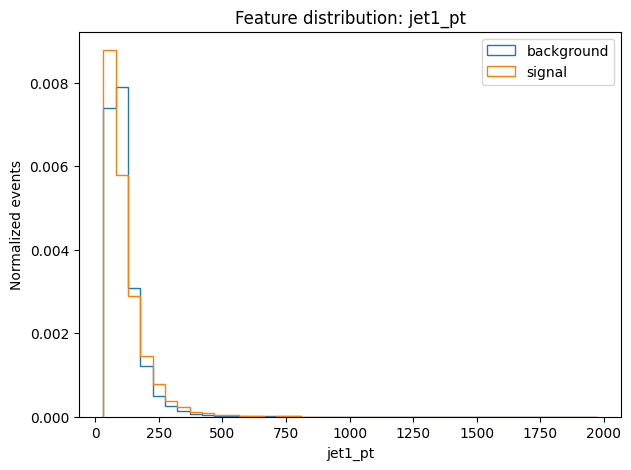

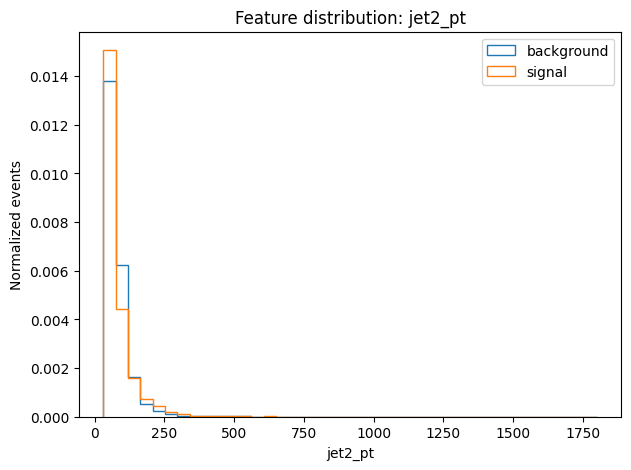

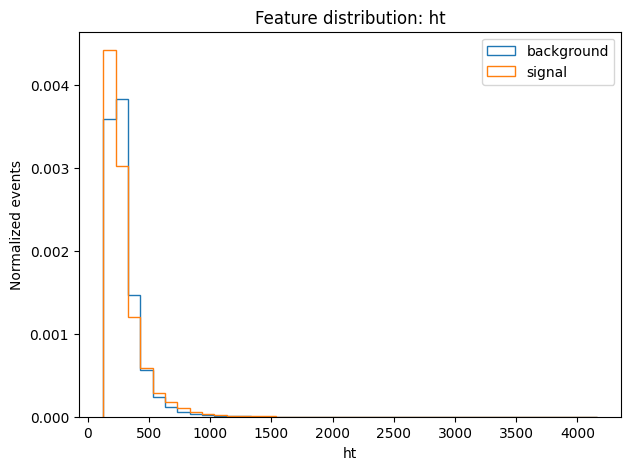

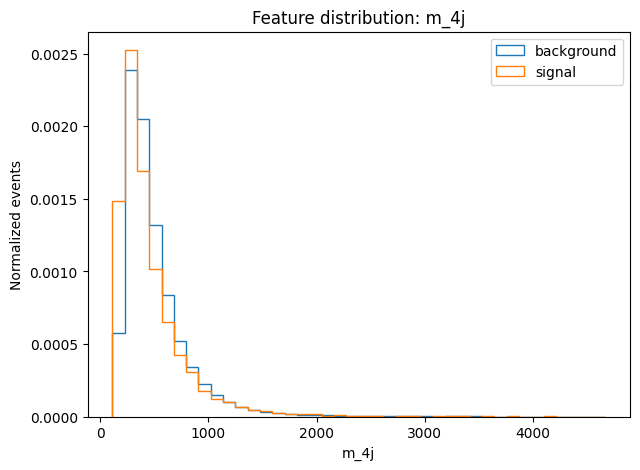

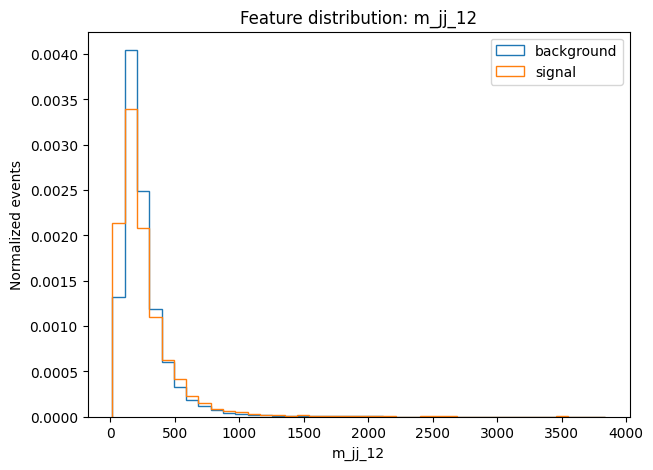

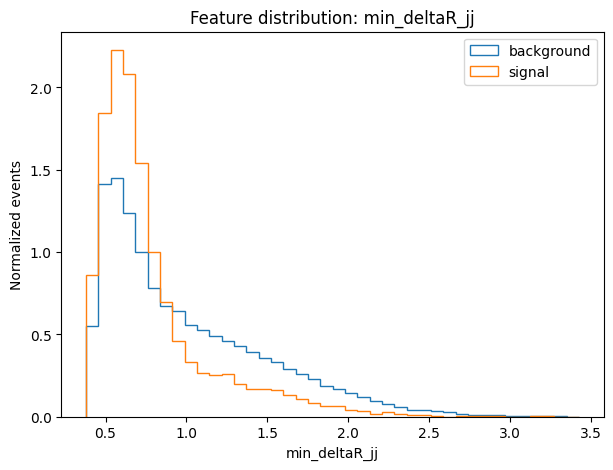

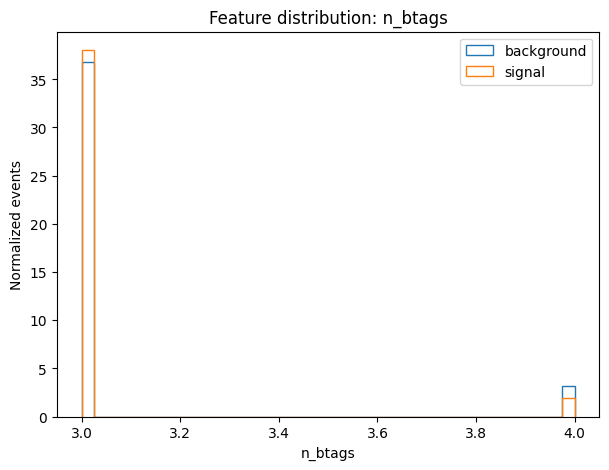

In [63]:
# Building a histogram of normalized features
for feature in ["jet1_pt", "jet2_pt", "ht", "m_4j", "m_jj_12", "min_deltaR_jj", "n_btags"]:
    if feature not in X.columns:
        continue
    values = X[feature].dropna().to_numpy()
    bins = np.histogram_bin_edges(values, bins=40)
    plt.figure()
    plt.hist(X.loc[y == 0, feature], bins=bins, histtype="step", density=True, label="background")
    plt.hist(X.loc[y == 1, feature], bins=bins, histtype="step", density=True, label="signal")
    plt.xlabel(feature)
    plt.ylabel("Normalized events")
    plt.title(f"Feature distribution: {feature}")
    plt.legend()
    plt.show()


## Section 3 - Classification Agent Template Class

`ClassificationAgent` handles shared bookkeeping: feature selection, train/validation/test splitting, optional scaling, metric calculation, and text summaries.

The class handles shared bookkeeping and dispatches to the selected model family:

| Method | Input | Output |
| --- | --- | --- |
| `.train(X, y)` | feature dataframe and label series | fitted classification agent with metrics |
| `.predict(X_new)` | dataframe with the selected feature columns | signal-like score for each row |

Most of the classifier work happens here. Add a new entry to `MODEL_LIBRARY`, then add the matching training block inside `ClassificationAgent.train(...)`. The planning agent can then choose that `model_family`.

In [64]:
def baseline_strategy(feature_columns):
    return {
        "strategy_name": "baseline_random_forest",
        "rationale": "Baseline random forest using all engineered four-jet features.",
        "feature_columns": list(feature_columns),
        "model_family": "random_forest",
        "hyperparameters": {"n_estimators": 160, "min_samples_leaf": 2, "max_features": "sqrt"},
    }


class ClassificationAgent:
    """Train and score one classifier chosen by a planning strategy.
    Add models in two places:
    1. Add a new entry to MODEL_LIBRARY.
    2. Add a new `elif self.model_family == "..."` block in train().
    predict() already works for scikit-learn classifiers with predict_proba.
    """
    # MODEL_LIBRARY maps classification model key/label to parameters (default and allowable to tune)
    MODEL_LIBRARY = {
        "random_forest": {
            "defaults": {"n_estimators": 160, "min_samples_leaf": 2, "max_depth": None, "max_features": "sqrt"},
            "allowed": {"n_estimators", "min_samples_leaf", "max_depth", "max_features"},
            "use_scaler": False,
        },
        # Logistic Regression: Fast, simple binary classification using regression fitting
        "logistic_regression": {
            "defaults": {"C": 1.0, "max_iter": 2000, "solver":"lbfgs", "class_weight":"balanced"},
            "allowed": {"C", "max_iter", "solver", "class_weight"},
            "use_scaler": True,
        },
        # Multi-layer perceptron: Flexible nonlinear classifier. Needs scaling. Can overfit.
        "mlp": {
            # Defaults: hidden layers of 32 and 16, ReLu as activation function, Adam as the solver, lr = 0.001, alpha adds L2 regularization.
            "defaults": {"hidden_layer_sizes": (128,128,64), "activation": "relu","solver": "adam", "alpha": 1e-4, "learning_rate_init": 0.001, "max_iter": 500},
            "allowed": {"hidden_layer_sizes", "activation", "solver", "alpha", "learning_rate_init", "max_iter"},
            "use_scaler": True,
        },
        # Extra Trees Clssification: Randomized tree ensemble similar to Random Forest. Often faster and more varied across trees.
        "extra_trees": {
            # Increaded number of estimators for stability
            "defaults": {"n_estimators": 500, "min_samples_leaf": 2, "max_depth": 6, "max_features": "sqrt", "min_samples_split": 10, "class_weight":'balanced'},
            "allowed": {"n_estimators", "min_samples_leaf", "max_depth", "max_features", "min_samples_split", "class_weight"},
            "use_scaler": False, # Scaling not needed
        },
        # Histogram-based Gradient Boosting Classification: Effficient through histogram. More hyperparameters. Increased risk of overfitting.
        "hist_gradient_boosting": {
            # max_iter is analagous to n_estimators.
            "defaults": {"max_iter": 1000, "learning_rate": 0.03, "max_leaf_nodes": 63, "min_samples_leaf": 20, "max_depth": 6, "l2_regularization":1.0, "max_features": 1.0},
            "allowed": {"max_iter", "learning_rate", "max_leaf_nodes", "min_samples_leaf", "max_depth", "l2_regularization","max_features"},
            "use_scaler": False, # Scaling not needed
        }

    }

    # Initialize object
    def __init__(self, strategy=None, random_state=RANDOM_STATE):
        self.strategy = strategy
        self.random_state = random_state
        self.name = (strategy or {}).get("strategy_name", "classification_agent")
        self.model_family = (strategy or {}).get("model_family", "random_forest")
        self.feature_names_ = []
        self.hyperparameters = {}
        self.scaler = None
        self.model = None
        self.metrics = {}
        self.n_trained = 0

    @classmethod
    def catalog(cls):
        return {
            name: {
                "defaults": config["defaults"],
                "allowed": config["allowed"],
                "use_scaler": config["use_scaler"],
            }
            for name, config in cls.MODEL_LIBRARY.items()
        }

    # Configures a chosen model to the object. Throws error if chosen model invalid.
    def _config(self):
        if self.model_family not in self.MODEL_LIBRARY:
            raise ValueError(f"Unknown model_family {self.model_family!r}. Choose one of {list(self.MODEL_LIBRARY)}.")
        return self.MODEL_LIBRARY[self.model_family]

    # Combines the allowed hyperparameters from the plan with defaults
    def _clean_hyperparameters(self):
        config = self._config()
        params = config["defaults"].copy()
        for key, value in (self.strategy.get("hyperparameters", {}) or {}).items():
            if key in config["allowed"]:
                params[key] = value
        return params

    # Collect values for classification, split data, scale
    def _prepare_data(self, X, y):
        if self.strategy is None:
            self.strategy = baseline_strategy(X.columns)
        self.name = self.strategy.get("strategy_name", "classification_agent")
        self.model_family = self.strategy.get("model_family", "random_forest")
        requested = self.strategy.get("feature_columns", [])
        self.feature_names_ = [col for col in requested if col in X.columns and pd.api.types.is_numeric_dtype(X[col])]
        if not self.feature_names_:
            raise ValueError("Classifier strategy did not select any valid numeric feature columns.")
        self.hyperparameters = self._clean_hyperparameters()

        # Split into training set (60%), validation set (50% of 40% = 20%), test (20%)
        X_selected = X[self.feature_names_].copy()
        self.X_train, X_temp, self.y_train, y_temp = train_test_split(
            X_selected, y, test_size=0.40, stratify=y, random_state=self.random_state
        )
        self.X_val, self.X_test, self.y_val, self.y_test = train_test_split(
            X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=self.random_state
        )

        # Scale data using standard scaling
        if self._config()["use_scaler"]:
            self.scaler = StandardScaler()
            self.X_train_model = self.scaler.fit_transform(self.X_train)
        else:
            self.scaler = None
            self.X_train_model = self.X_train

    # Scale input if set true for model
    def _model_input(self, X):
        X_selected = X[self.feature_names_].copy()
        return self.scaler.transform(X_selected) if self.scaler is not None else X_selected

    # Fit the classification model to the data
    def train(self, X, y):
        self._prepare_data(X, y)

        # If baseline of Random Forest Classifier
        if self.model_family == "random_forest":
            params = self.hyperparameters.copy()
            params["n_estimators"] = int(np.clip(int(params.get("n_estimators")), 50, 300))
            params["min_samples_leaf"] = int(np.clip(int(params.get("min_samples_leaf")), 1, 20))
            if params.get("max_depth") is not None:
                params["max_depth"] = int(np.clip(int(params["max_depth"]), 2, 40))
            if params.get("max_features") not in ["sqrt", "log2", None]:
                params["max_features"] = "sqrt"

            # Create the model and fit to data
            self.model = RandomForestClassifier(random_state=self.random_state, n_jobs=-1, **params)
            self.model.fit(self.X_train_model, self.y_train)

        # Added non-baseline models with training code below.
        # Each block should set `params`, create `self.model`, and fit it on self.X_train_model.

        # Elif Logistic Regression
        elif self.model_family == "logistic_regression":
            params = self.hyperparameters.copy()

            params["C"] = np.clip(float(params.get("C")), 0.01, 100.0)
            params["max_iter"] = int(np.clip(int(params.get("max_iter")), 100, 10000))
            if params.get("solver") not in ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]:
                params["solver"] = "lbfgs"
            if params.get("class_weight") not in ["balanced", None]:
                params["class_weight"] = "balanced"

            # Create the model and fit to data
            self.model = LogisticRegression(random_state=self.random_state, n_jobs=-1, **params)
            self.model.fit(self.X_train_model, self.y_train)


        # Elif Mulit-layer perceptron
        elif self.model_family == "mlp":
            params = self.hyperparameters.copy()

            if isinstance(params.get("hidden_layer_sizes"), str):
                params["hidden_layer_sizes"] = tuple(int(x.strip('[] ')) for x in params["hidden_layer_sizes"].split(","))
            else:
                params["hidden_layer_sizes"] = tuple(params.get("hidden_layer_sizes", (32, 16)))

            params["max_iter"] = int(np.clip(int(params.get("max_iter")), 100, 2000))

            self.model = MLPClassifier(random_state=self.random_state,  early_stopping=True, validation_fraction=0.1, **params)
            self.model.fit(self.X_train_model, self.y_train)

        # Elif ExtraTressClassifier
        elif self.model_family == "extra_trees":
          params = self.hyperparameters.copy()
          params["n_estimators"] = int(np.clip(int(params.get("n_estimators")), 50, 1000))
          params["min_samples_leaf"] = int(np.clip(int(params.get("min_samples_leaf", 2)), 1, 20))
          if params.get("max_depth") is not None:
              params["max_depth"] = int(np.clip(int(params["max_depth"]), 2, 40))
          if params.get("max_features") not in ["sqrt", "log2", None]:
              params["max_features"] = "sqrt"
          self.model = ExtraTreesClassifier(random_state=self.random_state, n_jobs=-1, **params)
          self.model.fit(self.X_train_model, self.y_train)

        # Elif HistGradientBoostingClassifier
        elif self.model_family == "hist_gradient_boosting":
          params = self.hyperparameters.copy()
          params["max_iter"] = int(np.clip(int(params.get("max_iter")), 50, 1500))
          params["min_samples_leaf"] = int(np.clip(int(params.get("min_samples_leaf", 20)), 5, 100))
          params["max_leaf_nodes"] = int(np.clip(int(params["max_leaf_nodes"]), 5, 100))
          params["max_depth"] = int(np.clip(int(params["max_depth"]), 2, 40))
          if params.get("max_features") in ['sqrt', 'log2']:
              params["max_features"] = None
          elif params.get("max_features") is not None:
              params["max_features"] = float(np.clip(float(params.get("max_features")), 0.1, 1.0))

          # Create the model and fit to data
          self.model = HistGradientBoostingClassifier(random_state=self.random_state, **params)
          self.model.fit(self.X_train_model, self.y_train)

        # Else throw an error
        else:
            raise ValueError(f"No training code is defined for model_family {self.model_family!r}.")

        self.hyperparameters = params
        self.n_trained += 1 # Track how many times the agent has been trained
        self.metrics["validation"] = self.evaluate(self.X_val, self.y_val)
        self.metrics["test"] = self.evaluate(self.X_test, self.y_test)
        return self

    # Predict probability of signal using current model
    def predict(self, X):
        scores = self.model.predict_proba(self._model_input(X))[:, 1]
        return np.clip(np.asarray(scores, dtype=float), 0.0, 1.0)

    # Evaluate and return the number of correct predictions, as well as resulting measures of success
    def evaluate(self, X, y):
        scores = self.predict(X)
        predictions = (scores >= 0.5).astype(int)
        return {
            "accuracy": accuracy_score(y, predictions),
            "auc": roc_auc_score(y, scores),
            "confusion_matrix": confusion_matrix(y, predictions),
            "classification_report": classification_report(y, predictions, zero_division=0),
            "scores": scores,
        }

    # Return the results of validation and testing for the model, as well as the final hyperparameters
    def describe(self):
        val_auc = self.metrics.get("validation", {}).get("auc", np.nan)
        test_auc = self.metrics.get("test", {}).get("auc", np.nan)
        return (
            f"ClassificationAgent `{self.name}` trained `{self.model_family}` using {len(self.feature_names_)} features.\n"
            f"Validation AUC = {val_auc:.3f}; test AUC = {test_auc:.3f}.\n"
            f"Hyperparameters: {self.hyperparameters}.\n\n"
        )

# Initialize the catalog of classification models
AGENT_CATALOG = ClassificationAgent.catalog()

# Initialize the baseline classification model
baseline_classifier = ClassificationAgent(strategy=baseline_strategy(X.columns))
baseline_classifier.train(X, y)
baseline_scores = baseline_classifier.predict(baseline_classifier.X_test)
print(baseline_classifier.describe())

ClassificationAgent `baseline_random_forest` trained `random_forest` using 37 features.
Validation AUC = 0.811; test AUC = 0.811.
Hyperparameters: {'n_estimators': 160, 'min_samples_leaf': 2, 'max_depth': None, 'max_features': 'sqrt'}.




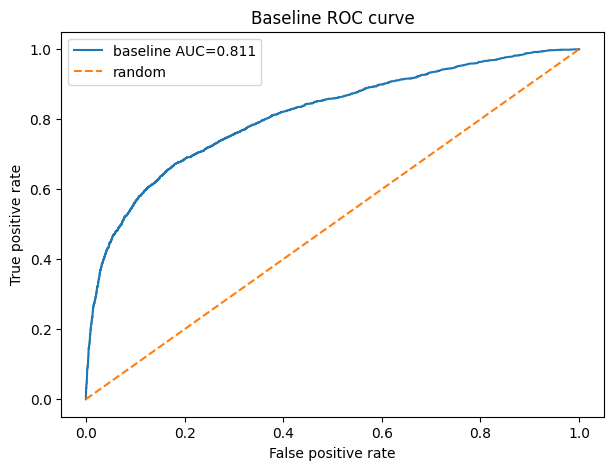

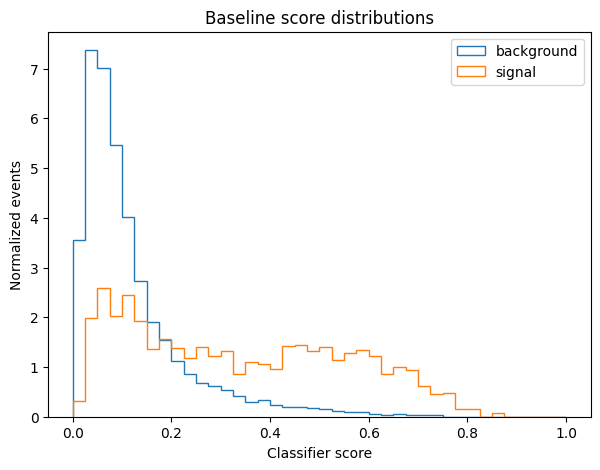

In [65]:
# Plot figures of the ROC compared to baseline

fpr, tpr, _ = roc_curve(baseline_classifier.y_test, baseline_scores)
plt.figure()
plt.plot(fpr, tpr, label=f"baseline AUC={baseline_classifier.metrics['test']['auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Baseline ROC curve")
plt.legend()
plt.show()

score_bins = np.linspace(0, 1, 41)
plt.figure()
plt.hist(baseline_scores[baseline_classifier.y_test.to_numpy() == 0], bins=score_bins, histtype="step", density=True, label="background")
plt.hist(baseline_scores[baseline_classifier.y_test.to_numpy() == 1], bins=score_bins, histtype="step", density=True, label="signal")
plt.xlabel("Classifier score")
plt.ylabel("Normalized events")
plt.title("Baseline score distributions")
plt.legend()
plt.show()


## Section 4 - Signal Analysis Agent Template Class

`SignalAnalysisAgent` turns classifier scores into a simple counting analysis.

Fill in the threshold scan yourself. For each threshold, select events with `scores >= threshold`, count selected signal and background events, compute efficiencies, and compute the counting significance $S/\sqrt{B}$.

,threshold,S,B,signal_efficiency,background_efficiency,S_over_sqrt_B
0,0.30,1111,995,0.515306,0.077312,35.221068
1,0.35,995,686,0.461503,0.053302,37.989277
2,0.40,878,485,0.407236,0.037685,39.867926
3,0.45,749,345,0.347403,0.026807,40.324804
4,0.50,600,227,0.278293,0.017638,39.823399
5,0.55,462,140,0.214286,0.010878,39.046127
6,0.60,321,79,0.148887,0.006138,36.115322
7,0.65,209,47,0.096939,0.003652,30.485783
8,0.70,104,19,0.048237,0.001476,23.859236
9,0.75,46,1,0.021336,0.000078,46.000000


SignalAnalysisAgent found the best threshold at score = 0.75, with S/sqrt(B) = 46.00.


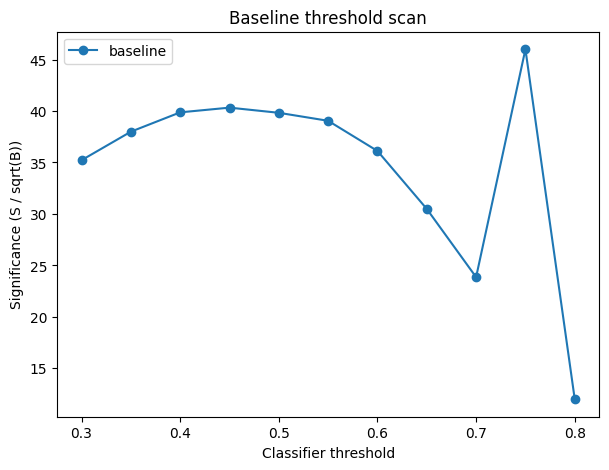

In [66]:
class SignalAnalysisAgent:
    def __init__(self, thresholds=None):
        self.thresholds = thresholds if thresholds is not None else np.arange(0.3, 1.0, 0.05)
        self.scan_table = None
        self.best = None

    def analyze(self, y_true, scores):
        y_true = pd.Series(y_true).astype(int).reset_index(drop=True)
        scores = np.asarray(scores, dtype=float)
        total_signal = max(int((y_true == 1).sum()), 1)
        total_background = max(int((y_true == 0).sum()), 1)
        # rows[] is map of threshold (row) to column values for: selected events | S | B | signal_efficiency | background_significance | significance
        rows = []

        # For each threshold:
        # - select events with scores >= threshold
        # - count selected signal events S
        # - count selected background events B
        # - compute signal efficiency S / total_signal
        # - compute background efficiency B / total_background
        # - compute counting significance S / sqrt(B)
        # - append one dictionary to rows with the columns used below

        for threshold in self.thresholds:
            # Filter events above threshhold
            selected = scores >= threshold
            # Count the number of signal and background events
            S = (y_true[selected] == 1).sum()
            B = (y_true[selected] == 0).sum()
            # Calculate efficiencies and significance
            signal_efficiency = S / total_signal
            background_efficiency = B / total_background
            significance = S / np.sqrt(B) if B > 0 else np.nan # Prevent divide by zero errors
            # Add the values to rows[]
            rows.append({
                "threshold": threshold,
                "S": S,
                "B": B,
                "signal_efficiency": signal_efficiency,
                "background_efficiency": background_efficiency,
                "S_over_sqrt_B": significance,
            })

        # Collect the values from rows into a sorted table. If none exist, raise error.
        self.scan_table = pd.DataFrame(rows)
        if self.scan_table.empty:
            raise ValueError("Threshold scan is empty. Finish SignalAnalysisAgent.analyze(...).")
        # Find the best threshhold, and return that threshhold and scan
        self.best = self.scan_table.sort_values("S_over_sqrt_B", ascending=False, na_position="last").iloc[0]
        return self.scan_table, self.best

    # Return a string describing the best threshold
    def describe(self):
        return (
            f"SignalAnalysisAgent found the best threshold at score = {self.best['threshold']:.2f}, "
            f"with S/sqrt(B) = {self.best['S_over_sqrt_B']:.2f}."
        )

# Initialize signal analysis of baseline Random Forest
signal_agent = SignalAnalysisAgent()
baseline_scan, baseline_best = signal_agent.analyze(baseline_classifier.y_test, baseline_scores)
display(baseline_scan)
print(signal_agent.describe())

# Plot best scan found in baseline threshhold scan
plt.figure()
plt.plot(baseline_scan["threshold"], baseline_scan["S_over_sqrt_B"], marker="o", label="baseline")
plt.xlabel("Classifier threshold")
plt.ylabel("Significance (S / sqrt(B))")
plt.title("Baseline threshold scan")
plt.legend()
plt.show()

## Section 5 - Planning Agent Template Class

The planning agent reads previous round results and proposes the next classifier strategy. It does not write executable classifier code.

The API call, JSON parsing, and validation are fixed infrastructure. Edit `PLANNING_PROMPT` to direct the strategy: which features to try, which model families to prefer, how much to explore, and how to react to previous results.

Example planning-agent output:

```python
{
    "strategy_name": "extra_trees_mass_and_btag_scan",
    "rationale": "Try a high-capacity tree model using invariant-mass, angular-separation, and b-tag variables that match the four-b signal topology.",
    "feature_columns": [
        "ht",
        "m_4j",
        "m_jj_12",
        "m_jj_13",
        "m_jj_14",
        "m_jj_23",
        "m_jj_24",
        "m_jj_34",
        "min_deltaR_jj",
        "mean_deltaR_jj",
        "n_btags",
    ],
    "model_family": "extra_trees",
    "hyperparameters": {
        "n_estimators": 220,
        "min_samples_leaf": 1,
        "max_features": "sqrt"
    }
}
```

In [67]:
# Add strategy instructions for the planning agent.
# Examples of strategy guidance:
# - Which physics features should it try first?
# - Should it explore new model families or tune the current best one?
# - Should it prefer simple models, high-capacity models, or MLPs?
# - How should it use the previous round history?

PLANNING_PROMPT = """
Return exactly ONE valid JSON dictionary containing the next classifier strategy.
The JSON must strictly contain these keys: "strategy_name", "rationale", "feature_columns", "model_family", "hyperparameters".

Primary objective: maximize best_S_over_sqrt_B.
Your goal is to successfully construct a strategy that improves on the baseline `S_over_sqrt_b` score within 10 planning rounds using a model different from the baseline model family with default parameters.

Use the following decision policy:

1. Treat the current best round as the incumbent. The baseline random_forest is not an incumbent.
2. If a proposed strategy changes features, model family, or hyperparameters, explain why that change is expected to increase best_S_over_sqrt_B specifically.
3. Do not use fewer than 30 features unless a previous reduced-feature round beat the all-feature incumbent.
4. If a model family has the highest best_S_over_sqrt_B, spend the next round refining that model family with all features.
5. Do not repeat a previous combination of model_family, feature_columns, and hyperparameters listed in history. Instead, adjust the hyperparameters to improve the model's performance.
6. Make only one major change per round when refining the incumbent, so history is interpretable.
7. Prefer all 37 features for tree and boosting models.
8. Avoid extra_trees unless a previous extra_trees round is within 5% of the incumbent. Avoid random_forest.
9. If changing a parameter has less than a 2% effect on best_S_over_sqrt_B, do not change it again for that model family.
9. Report whether the proposed plan is exploration or refinement.

Allowed Model Families & Parameter Keys (Strict Match):
- "hist_gradient_boosting": ["max_iter", "learning_rate", "max_leaf_nodes", "min_samples_leaf", "max_depth", "l2_regularization", "max_features"]
- "extra_trees": ["n_estimators", "min_samples_leaf", "max_depth", "max_features", "min_samples_split"]
- "mlp": ["hidden_layer_sizes", "activation", "solver", "alpha", "learning_rate_init", "max_iter"]
- "logistic_regression": ["C", "max_iter", "solver", "class_weight"]

Return only valid JSON.
""".strip()


class PlanningAgent:
    def __init__(self, prompt=PLANNING_PROMPT, model_templates=AGENT_CATALOG, api_key=CEREBRAS_API_KEY, model_name=CEREBRAS_MODEL):
        self.prompt = prompt
        self.model_templates = model_templates
        self.api_key = api_key
        self.model_name = model_name
        self.last_plan = None

    def plan(self, history, dataset_summary, baseline_summary):
        sleep(10) # 5 sec delay to try to prevent cerebras per-min quota error
        self.last_plan = request_strategy_from_cerebras(
            prompt=self.prompt,
            history=history,
            dataset_summary=dataset_summary,
            baseline_summary=baseline_summary,
            model_templates=self.model_templates,
            api_key=self.api_key,
            model_name=self.model_name,
        )
        return self.last_plan

    def describe(self, plan=None):
        plan = plan or self.last_plan
        return (
            f"PlanningAgent proposed `{plan['strategy_name']}`: a `{plan['model_family']}` strategy "
            f"using {len(plan['feature_columns'])} features. Rationale: {plan['rationale']}"
        )

    def summarize_round(self, round_id, plan, classifier_agent, best):
        return summarize_planning_round(round_id, plan, classifier_agent, best)

### Baseline Agentic Workflow

This cell runs the same agent sequence once without an LLM-planned strategy. It gives a baseline random-forest result to compare against later.

Inputs: `X`, `y`, and `baseline_classifier` from the previous sections.

Outputs: `baseline_summary`, `baseline_scan`, `baseline_best`, and diagnostic plots.

In [68]:
baseline_summary = {
    "model": baseline_classifier.name,
    "test_auc": baseline_classifier.metrics["test"]["auc"],
    "best_threshold": baseline_best["threshold"],
    "best_S_over_sqrt_B": baseline_best["S_over_sqrt_B"],
}
display(pd.DataFrame([baseline_summary]))


,model,test_auc,best_threshold,best_S_over_sqrt_B
0,baseline_random_forest,0.811072,0.75,46.0


### Agentic Planning Loop

Complete the orchestration loop. The loop should pass information from one agent to the next, save each round result, and update `history` so the planning agent can react to previous attempts.


Planning round 1
FeatureAgent `four_jet_feature_agent` built 37 ML features for 75,126 selected events.
PlanningAgent proposed `physics_mass_exploration`: a `hist_gradient_boosting` strategy using 37 features. Rationale: Explore a different model family to potentially improve performance.
ClassificationAgent `physics_mass_exploration` trained `hist_gradient_boosting` using 37 features.
Validation AUC = 0.821; test AUC = 0.822.
Hyperparameters: {'max_iter': 1100, 'learning_rate': 0.032, 'max_leaf_nodes': 63, 'min_samples_leaf': 20, 'max_depth': 6, 'l2_regularization': 1.0, 'max_features': 1.0}.


SignalAnalysisAgent found the best threshold at score = 0.60, with S/sqrt(B) = 42.52.


,round,strategy,model_family,features_used,hyperparameters,test_auc,best_threshold,best_S_over_sqrt_B,rationale
0,1,physics_mass_exploration,hist_gradient_boosting,37,"{""l2_regularization"": 1.0, ""learning_rate"": 0....",0.822011,0.6,42.518383,Explore a different model family to potentiall...


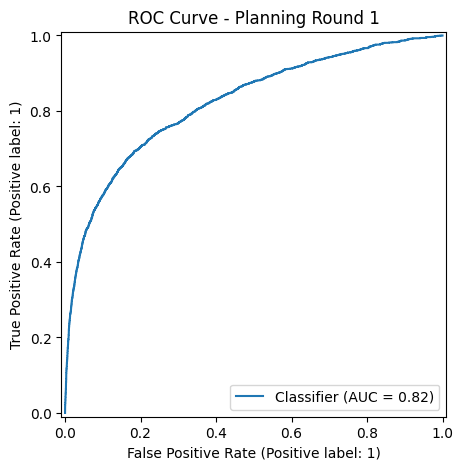

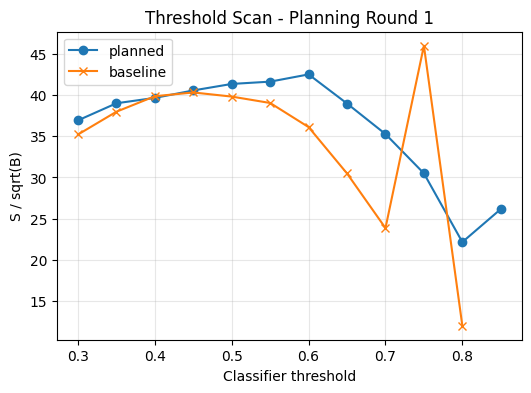


Planning round 2
FeatureAgent `four_jet_feature_agent` built 37 ML features for 75,126 selected events.
PlanningAgent proposed `incumbent_refine_hist_gradient_boosting`: a `hist_gradient_boosting` strategy using 37 features. Rationale: Refine the best-performing HistGradientBoosting family model to further improve its AUC and S_over_sqrt_B score.
ClassificationAgent `incumbent_refine_hist_gradient_boosting` trained `hist_gradient_boosting` using 37 features.
Validation AUC = 0.821; test AUC = 0.820.
Hyperparameters: {'max_iter': 1000, 'learning_rate': 0.03, 'max_leaf_nodes': 63, 'min_samples_leaf': 20, 'max_depth': 6, 'l2_regularization': 0.5, 'max_features': 1.0}.


SignalAnalysisAgent found the best threshold at score = 0.50, with S/sqrt(B) = 41.95.


,round,strategy,model_family,features_used,hyperparameters,test_auc,best_threshold,best_S_over_sqrt_B,rationale
0,1,physics_mass_exploration,hist_gradient_boosting,37,"{""l2_regularization"": 1.0, ""learning_rate"": 0....",0.822011,0.6,42.518383,Explore a different model family to potentiall...
1,2,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.5,41.953682,Refine the best-performing HistGradientBoostin...


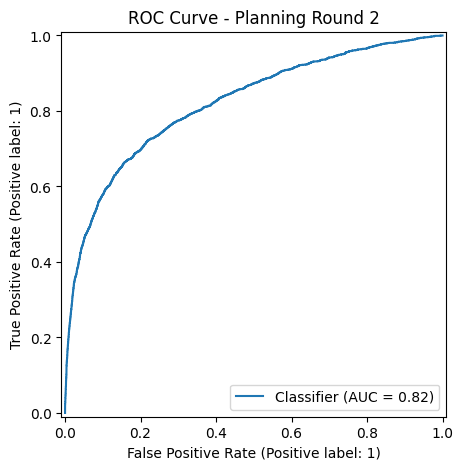

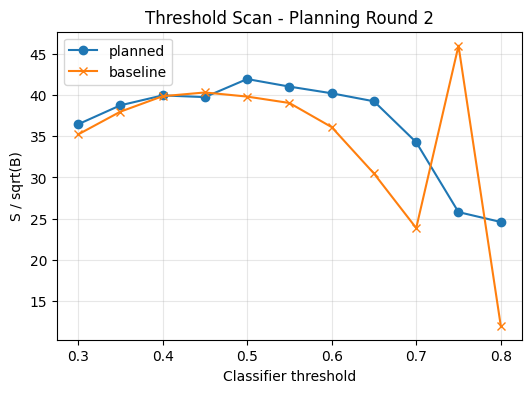


Planning round 3
FeatureAgent `four_jet_feature_agent` built 37 ML features for 75,126 selected events.
PlanningAgent proposed `incumbent_refine_hist_gradient_boosting`: a `hist_gradient_boosting` strategy using 37 features. Rationale: Refine the best-performing HistGradientBoosting family model to further improve its AUC and S_over_sqrt_B score.
ClassificationAgent `incumbent_refine_hist_gradient_boosting` trained `hist_gradient_boosting` using 37 features.
Validation AUC = 0.821; test AUC = 0.820.
Hyperparameters: {'max_iter': 1000, 'learning_rate': 0.03, 'max_leaf_nodes': 63, 'min_samples_leaf': 20, 'max_depth': 6, 'l2_regularization': 0.5, 'max_features': 1.0}.


SignalAnalysisAgent found the best threshold at score = 0.50, with S/sqrt(B) = 41.95.


,round,strategy,model_family,features_used,hyperparameters,test_auc,best_threshold,best_S_over_sqrt_B,rationale
0,1,physics_mass_exploration,hist_gradient_boosting,37,"{""l2_regularization"": 1.0, ""learning_rate"": 0....",0.822011,0.6,42.518383,Explore a different model family to potentiall...
1,2,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.5,41.953682,Refine the best-performing HistGradientBoostin...
2,3,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.5,41.953682,Refine the best-performing HistGradientBoostin...


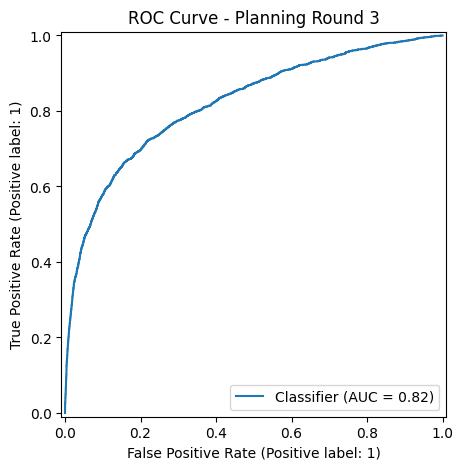

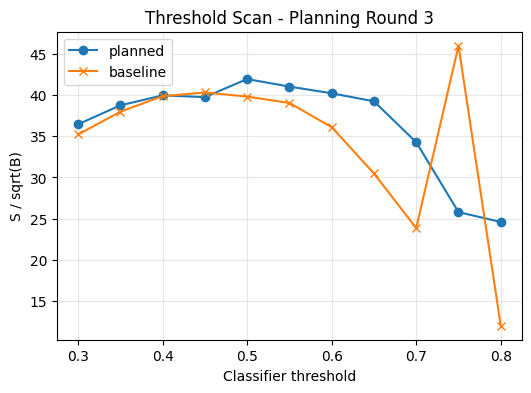


Planning round 4
FeatureAgent `four_jet_feature_agent` built 37 ML features for 75,126 selected events.
PlanningAgent proposed `incumbent_refine_hist_gradient_boosting`: a `hist_gradient_boosting` strategy using 37 features. Rationale: Refine the best-performing HistGradientBoosting family model to further improve its AUC and S_over_sqrt_B score.
ClassificationAgent `incumbent_refine_hist_gradient_boosting` trained `hist_gradient_boosting` using 37 features.
Validation AUC = 0.821; test AUC = 0.822.
Hyperparameters: {'max_iter': 1000, 'learning_rate': 0.035, 'max_leaf_nodes': 63, 'min_samples_leaf': 20, 'max_depth': 6, 'l2_regularization': 0.5, 'max_features': 1.0}.


SignalAnalysisAgent found the best threshold at score = 0.55, with S/sqrt(B) = 42.10.


,round,strategy,model_family,features_used,hyperparameters,test_auc,best_threshold,best_S_over_sqrt_B,rationale
0,1,physics_mass_exploration,hist_gradient_boosting,37,"{""l2_regularization"": 1.0, ""learning_rate"": 0....",0.822011,0.60,42.518383,Explore a different model family to potentiall...
1,2,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.50,41.953682,Refine the best-performing HistGradientBoostin...
2,3,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.50,41.953682,Refine the best-performing HistGradientBoostin...
3,4,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.821867,0.55,42.104995,Refine the best-performing HistGradientBoostin...


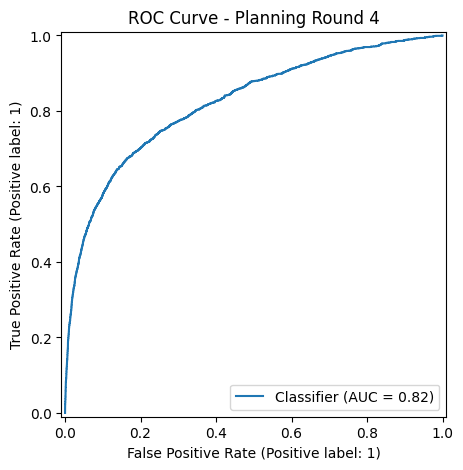

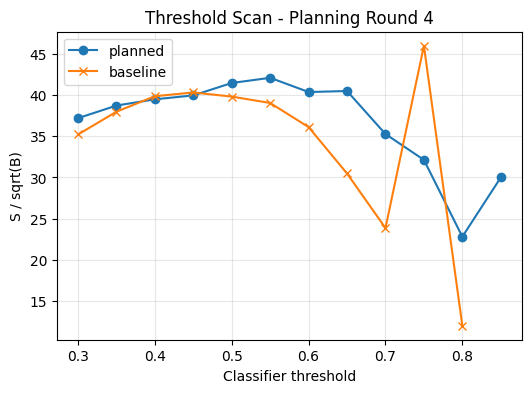


Planning round 5
FeatureAgent `four_jet_feature_agent` built 37 ML features for 75,126 selected events.
PlanningAgent proposed `incumbent_refine_hist_gradient_boosting`: a `hist_gradient_boosting` strategy using 37 features. Rationale: Refine the best-performing HistGradientBoosting family model to further improve its AUC and S_over_sqrt_B score.
ClassificationAgent `incumbent_refine_hist_gradient_boosting` trained `hist_gradient_boosting` using 37 features.
Validation AUC = 0.821; test AUC = 0.820.
Hyperparameters: {'max_iter': 1000, 'learning_rate': 0.035, 'max_leaf_nodes': 63, 'min_samples_leaf': 20, 'max_depth': 6, 'l2_regularization': 0.3, 'max_features': 1.0}.


SignalAnalysisAgent found the best threshold at score = 0.60, with S/sqrt(B) = 42.11.


,round,strategy,model_family,features_used,hyperparameters,test_auc,best_threshold,best_S_over_sqrt_B,rationale
0,1,physics_mass_exploration,hist_gradient_boosting,37,"{""l2_regularization"": 1.0, ""learning_rate"": 0....",0.822011,0.60,42.518383,Explore a different model family to potentiall...
1,2,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.50,41.953682,Refine the best-performing HistGradientBoostin...
2,3,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.50,41.953682,Refine the best-performing HistGradientBoostin...
3,4,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.821867,0.55,42.104995,Refine the best-performing HistGradientBoostin...
4,5,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.3, ""learning_rate"": 0....",0.819836,0.60,42.111039,Refine the best-performing HistGradientBoostin...


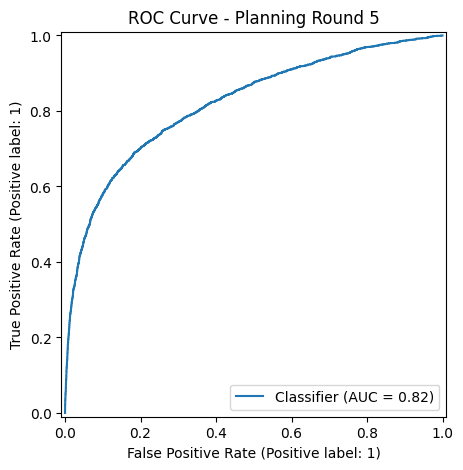

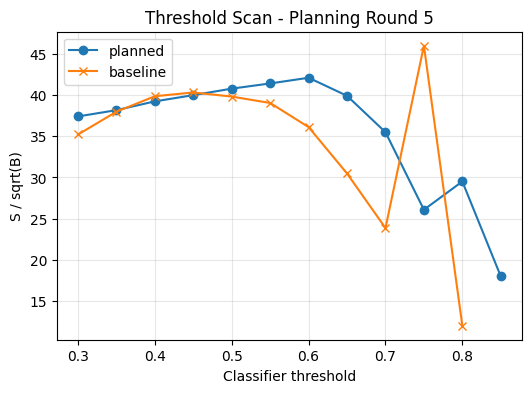


Planning round 6
FeatureAgent `four_jet_feature_agent` built 37 ML features for 75,126 selected events.
PlanningAgent proposed `incumbent_refine_hist_gradient_boosting`: a `hist_gradient_boosting` strategy using 37 features. Rationale: Refine the best-performing HistGradientBoosting family model to further improve its AUC and S_over_sqrt_B score.
ClassificationAgent `incumbent_refine_hist_gradient_boosting` trained `hist_gradient_boosting` using 37 features.
Validation AUC = 0.820; test AUC = 0.821.
Hyperparameters: {'max_iter': 1000, 'learning_rate': 0.035, 'max_leaf_nodes': 63, 'min_samples_leaf': 20, 'max_depth': 6, 'l2_regularization': 0.8, 'max_features': 1.0}.


SignalAnalysisAgent found the best threshold at score = 0.60, with S/sqrt(B) = 42.82.


,round,strategy,model_family,features_used,hyperparameters,test_auc,best_threshold,best_S_over_sqrt_B,rationale
0,1,physics_mass_exploration,hist_gradient_boosting,37,"{""l2_regularization"": 1.0, ""learning_rate"": 0....",0.822011,0.60,42.518383,Explore a different model family to potentiall...
1,2,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.50,41.953682,Refine the best-performing HistGradientBoostin...
2,3,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.50,41.953682,Refine the best-performing HistGradientBoostin...
3,4,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.821867,0.55,42.104995,Refine the best-performing HistGradientBoostin...
4,5,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.3, ""learning_rate"": 0....",0.819836,0.60,42.111039,Refine the best-performing HistGradientBoostin...
5,6,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.8, ""learning_rate"": 0....",0.821215,0.60,42.824786,Refine the best-performing HistGradientBoostin...


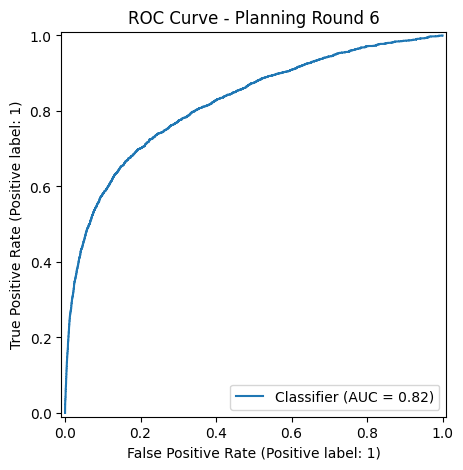

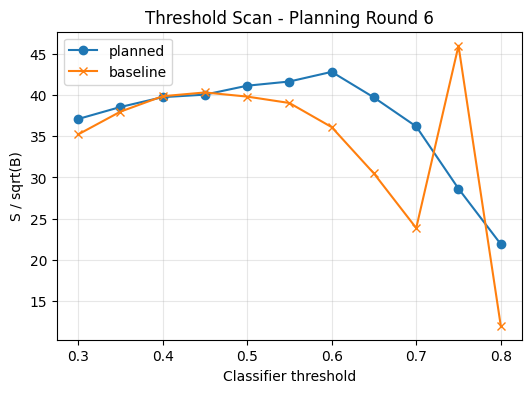


Planning round 7
FeatureAgent `four_jet_feature_agent` built 37 ML features for 75,126 selected events.
PlanningAgent proposed `refine_incumbent_hist_gradient_boosting`: a `hist_gradient_boosting` strategy using 37 features. Rationale: Refine the best-performing HistGradientBoosting family model to further improve its AUC and S_over_sqrt_B score.
ClassificationAgent `refine_incumbent_hist_gradient_boosting` trained `hist_gradient_boosting` using 37 features.
Validation AUC = 0.821; test AUC = 0.822.
Hyperparameters: {'max_iter': 1050, 'learning_rate': 0.032, 'max_leaf_nodes': 63, 'min_samples_leaf': 22, 'max_depth': 6, 'l2_regularization': 0.4, 'max_features': 1.0}.


SignalAnalysisAgent found the best threshold at score = 0.50, with S/sqrt(B) = 42.05.


,round,strategy,model_family,features_used,hyperparameters,test_auc,best_threshold,best_S_over_sqrt_B,rationale
0,1,physics_mass_exploration,hist_gradient_boosting,37,"{""l2_regularization"": 1.0, ""learning_rate"": 0....",0.822011,0.60,42.518383,Explore a different model family to potentiall...
1,2,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.50,41.953682,Refine the best-performing HistGradientBoostin...
2,3,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.50,41.953682,Refine the best-performing HistGradientBoostin...
3,4,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.821867,0.55,42.104995,Refine the best-performing HistGradientBoostin...
4,5,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.3, ""learning_rate"": 0....",0.819836,0.60,42.111039,Refine the best-performing HistGradientBoostin...
5,6,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.8, ""learning_rate"": 0....",0.821215,0.60,42.824786,Refine the best-performing HistGradientBoostin...
6,7,refine_incumbent_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.4, ""learning_rate"": 0....",0.821768,0.50,42.053366,Refine the best-performing HistGradientBoostin...


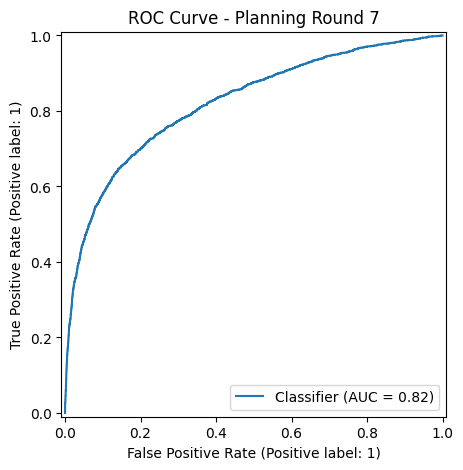

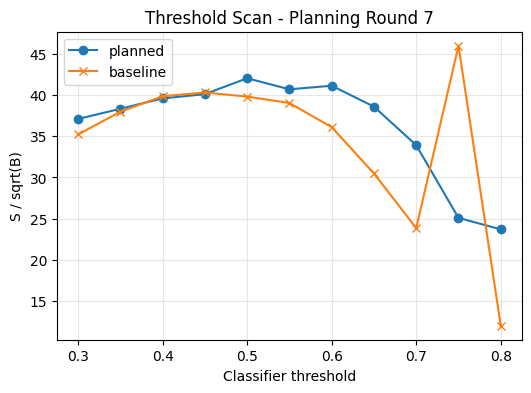


Planning round 8
FeatureAgent `four_jet_feature_agent` built 37 ML features for 75,126 selected events.
PlanningAgent proposed `physics_mass_exploration`: a `mlp` strategy using 37 features. Rationale: Explore a different model family to potentially improve performance.
ClassificationAgent `physics_mass_exploration` trained `mlp` using 37 features.
Validation AUC = 0.773; test AUC = 0.783.
Hyperparameters: {'hidden_layer_sizes': (128, 128, 64), 'activation': 'relu', 'solver': 'adam', 'alpha': 0.0001, 'learning_rate_init': 0.001, 'max_iter': 500}.


SignalAnalysisAgent found the best threshold at score = 0.35, with S/sqrt(B) = 31.99.


,round,strategy,model_family,features_used,hyperparameters,test_auc,best_threshold,best_S_over_sqrt_B,rationale
0,1,physics_mass_exploration,hist_gradient_boosting,37,"{""l2_regularization"": 1.0, ""learning_rate"": 0....",0.822011,0.60,42.518383,Explore a different model family to potentiall...
1,2,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.50,41.953682,Refine the best-performing HistGradientBoostin...
2,3,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.50,41.953682,Refine the best-performing HistGradientBoostin...
3,4,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.821867,0.55,42.104995,Refine the best-performing HistGradientBoostin...
4,5,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.3, ""learning_rate"": 0....",0.819836,0.60,42.111039,Refine the best-performing HistGradientBoostin...
5,6,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.8, ""learning_rate"": 0....",0.821215,0.60,42.824786,Refine the best-performing HistGradientBoostin...
6,7,refine_incumbent_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.4, ""learning_rate"": 0....",0.821768,0.50,42.053366,Refine the best-performing HistGradientBoostin...
7,8,physics_mass_exploration,mlp,37,"{""activation"": ""relu"", ""alpha"": 0.0001, ""hidde...",0.783254,0.35,31.986624,Explore a different model family to potentiall...


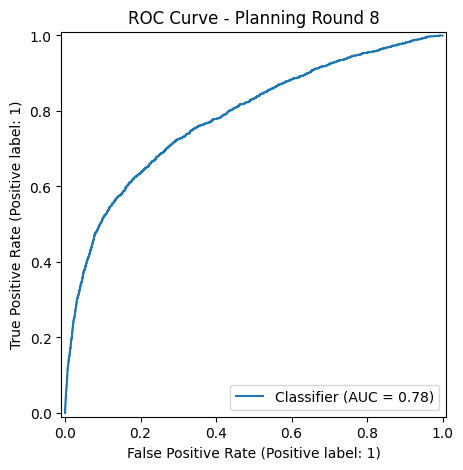

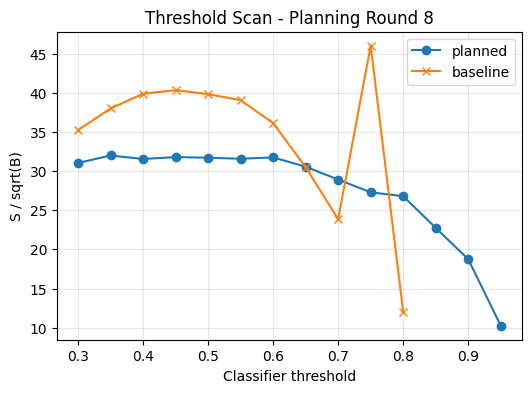


Planning round 9
FeatureAgent `four_jet_feature_agent` built 37 ML features for 75,126 selected events.
PlanningAgent proposed `incumbent_refine_hist_gradient_boosting`: a `hist_gradient_boosting` strategy using 37 features. Rationale: Refine the best-performing HistGradientBoosting family model to further improve its AUC and S_over_sqrt_B score.
ClassificationAgent `incumbent_refine_hist_gradient_boosting` trained `hist_gradient_boosting` using 37 features.
Validation AUC = 0.822; test AUC = 0.821.
Hyperparameters: {'max_iter': 1000, 'learning_rate': 0.035, 'max_leaf_nodes': 63, 'min_samples_leaf': 20, 'max_depth': 6, 'l2_regularization': 0.45, 'max_features': 1.0}.


SignalAnalysisAgent found the best threshold at score = 0.55, with S/sqrt(B) = 41.73.


,round,strategy,model_family,features_used,hyperparameters,test_auc,best_threshold,best_S_over_sqrt_B,rationale
0,1,physics_mass_exploration,hist_gradient_boosting,37,"{""l2_regularization"": 1.0, ""learning_rate"": 0....",0.822011,0.60,42.518383,Explore a different model family to potentiall...
1,2,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.50,41.953682,Refine the best-performing HistGradientBoostin...
2,3,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.50,41.953682,Refine the best-performing HistGradientBoostin...
3,4,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.821867,0.55,42.104995,Refine the best-performing HistGradientBoostin...
4,5,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.3, ""learning_rate"": 0....",0.819836,0.60,42.111039,Refine the best-performing HistGradientBoostin...
5,6,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.8, ""learning_rate"": 0....",0.821215,0.60,42.824786,Refine the best-performing HistGradientBoostin...
6,7,refine_incumbent_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.4, ""learning_rate"": 0....",0.821768,0.50,42.053366,Refine the best-performing HistGradientBoostin...
7,8,physics_mass_exploration,mlp,37,"{""activation"": ""relu"", ""alpha"": 0.0001, ""hidde...",0.783254,0.35,31.986624,Explore a different model family to potentiall...
8,9,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.45, ""learning_rate"": 0...",0.820574,0.55,41.731258,Refine the best-performing HistGradientBoostin...


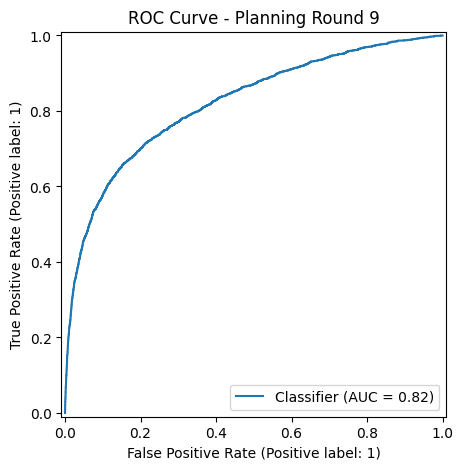

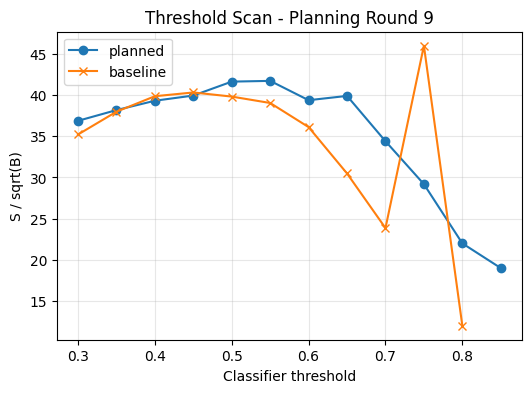


Planning round 10
FeatureAgent `four_jet_feature_agent` built 37 ML features for 75,126 selected events.
PlanningAgent proposed `incumbent_refine_hist_gradient_boosting`: a `hist_gradient_boosting` strategy using 37 features. Rationale: Refine the best-performing HistGradientBoosting family model to further improve its AUC and S_over_sqrt_B score.
ClassificationAgent `incumbent_refine_hist_gradient_boosting` trained `hist_gradient_boosting` using 37 features.
Validation AUC = 0.821; test AUC = 0.821.
Hyperparameters: {'max_iter': 1000, 'learning_rate': 0.035, 'max_leaf_nodes': 63, 'min_samples_leaf': 20, 'max_depth': 6, 'l2_regularization': 0.85, 'max_features': 1.0}.


SignalAnalysisAgent found the best threshold at score = 0.55, with S/sqrt(B) = 41.83.


,round,strategy,model_family,features_used,hyperparameters,test_auc,best_threshold,best_S_over_sqrt_B,rationale
0,1,physics_mass_exploration,hist_gradient_boosting,37,"{""l2_regularization"": 1.0, ""learning_rate"": 0....",0.822011,0.60,42.518383,Explore a different model family to potentiall...
1,2,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.50,41.953682,Refine the best-performing HistGradientBoostin...
2,3,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.820123,0.50,41.953682,Refine the best-performing HistGradientBoostin...
3,4,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.5, ""learning_rate"": 0....",0.821867,0.55,42.104995,Refine the best-performing HistGradientBoostin...
4,5,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.3, ""learning_rate"": 0....",0.819836,0.60,42.111039,Refine the best-performing HistGradientBoostin...
5,6,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.8, ""learning_rate"": 0....",0.821215,0.60,42.824786,Refine the best-performing HistGradientBoostin...
6,7,refine_incumbent_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.4, ""learning_rate"": 0....",0.821768,0.50,42.053366,Refine the best-performing HistGradientBoostin...
7,8,physics_mass_exploration,mlp,37,"{""activation"": ""relu"", ""alpha"": 0.0001, ""hidde...",0.783254,0.35,31.986624,Explore a different model family to potentiall...
8,9,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.45, ""learning_rate"": 0...",0.820574,0.55,41.731258,Refine the best-performing HistGradientBoostin...
9,10,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,"{""l2_regularization"": 0.85, ""learning_rate"": 0...",0.821482,0.55,41.828220,Refine the best-performing HistGradientBoostin...


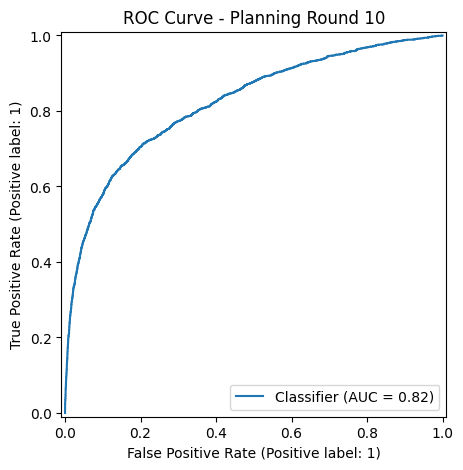

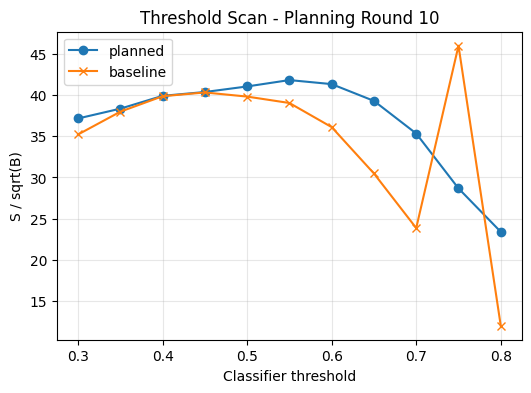

In [70]:
NUM_PLANNING_ROUNDS = 10
history = []
planned_results = []
planning_agent = PlanningAgent()

for round_id in range(1, NUM_PLANNING_ROUNDS + 1):
    print(f"\nPlanning round {round_id}")

    # Create a FeatureAgent and build X, y from selected_events.
    feature_agent = FeatureAgent()
    X, y = feature_agent.features(selected_events)
    print(feature_agent.describe())

    # Build dataset_summary for the planning agent.
    # It should include event count, feature count, class counts, and feature names.
    eventCount = len(X)
    featureNames = X.columns
    featureCount = len(X.columns)
    classCounts = y.value_counts()
    dataset_summary = {
        "event_count": int(len(X)),
        "feature_count": int(len(X.columns)),
        "class_counts": y.value_counts().sort_index().astype(int).to_dict(),
        "feature_names": list(X.columns),
    }

    # Ask the planning agent for the next strategy.
    plan = planning_agent.plan(history=history, dataset_summary=dataset_summary, baseline_summary=baseline_summary)

    # # Enforce rules for planning
    # plan = planning_agent.enforce_planning_rules(history, dataset_summary, baseline_summary)

    print(planning_agent.describe(plan))

    # Train the ClassificationAgent using the planned strategy.
    classification_agent = ClassificationAgent(strategy=plan)
    classification_agent.train(X, y)
    scores = classification_agent.predict(classification_agent.X_test)
    print(classification_agent.describe())

    # Run the SignalAnalysisAgent threshold scan.
    signal_agent = SignalAnalysisAgent()
    scan, best = signal_agent.analyze(classification_agent.y_test, scores)
    print(signal_agent.describe())

    # Save the full round result in planned_results.
    planned_results.append({
        "scan": scan,
        "best": best,
        "agent": classification_agent,
        "plan": plan,
        "scores": scores,
    })

    # Summarize the round and append it to history.
    plan_for_history = plan.copy()
    plan_for_history["hyperparameters"] = classification_agent.hyperparameters
    round_summary = planning_agent.summarize_round(round_id, plan_for_history, classification_agent, best)
    history.append(round_summary)

    if len(planned_results) < round_id:
        raise NotImplementedError("Complete the orchestration TODOs above before plotting round results.")

    # The displays below should work after the variables above are defined.
    display(pd.DataFrame(history))

    RocCurveDisplay.from_predictions(classification_agent.y_test, scores)
    plt.title(f"ROC Curve - Planning Round {round_id}")
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(scan["threshold"], scan["S_over_sqrt_B"], marker="o")
    plt.plot(baseline_scan["threshold"], baseline_scan["S_over_sqrt_B"], marker="x")
    plt.xlabel("Classifier threshold")
    plt.ylabel("S / sqrt(B)")
    plt.legend(["planned", "baseline"])
    plt.title(f"Threshold Scan - Planning Round {round_id}")
    plt.grid(True, alpha=0.3)
    plt.show()

### Final Baseline versus Best Planned Model Comparison

This final comparison selects the planned model with the best threshold-scan value of $S/\sqrt{B}$, then compares it with the baseline random-forest workflow.

Baseline model:
ClassificationAgent `baseline_random_forest` trained `random_forest` using 37 features.
Validation AUC = 0.811; test AUC = 0.811.
Hyperparameters: {'n_estimators': 160, 'min_samples_leaf': 2, 'max_depth': None, 'max_features': 'sqrt'}.


Baseline best S/sqrt(B) = 46.00 at threshold 0.75.

Best planned model:
ClassificationAgent `incumbent_refine_hist_gradient_boosting` trained `hist_gradient_boosting` using 37 features.
Validation AUC = 0.820; test AUC = 0.821.
Hyperparameters: {'max_iter': 1000, 'learning_rate': 0.035, 'max_leaf_nodes': 63, 'min_samples_leaf': 20, 'max_depth': 6, 'l2_regularization': 0.8, 'max_features': 1.0}.


Best planned S/sqrt(B) = 42.82 at threshold 0.60.
Planning rationale: Refine the best-performing HistGradientBoosting family model to further improve its AUC and S_over_sqrt_B score.
Features used (37): jet1_pt, jet1_eta, jet1_phi, jet1_mass, jet1_btag, jet2_pt, jet2_eta, jet2_phi, jet2_mass, jet2_btag, jet3_pt, jet3_eta, jet3_phi, jet3_mass, j

,model,strategy,model_family,features_used,test_auc,best_threshold,best_S_over_sqrt_B
0,baseline,baseline_random_forest,random_forest,37,0.811072,0.75,46.000000
1,best_planned,incumbent_refine_hist_gradient_boosting,hist_gradient_boosting,37,0.821215,0.60,42.824786


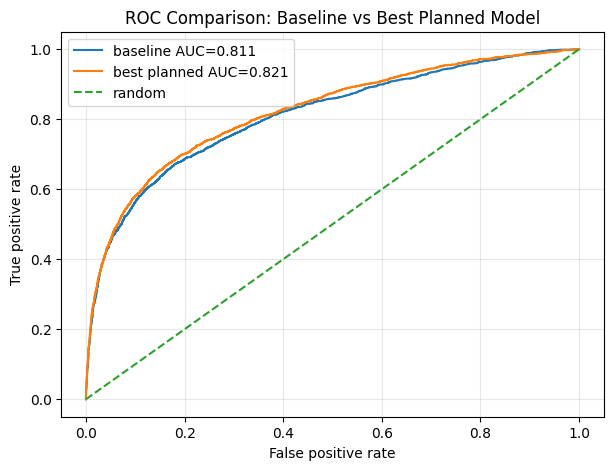

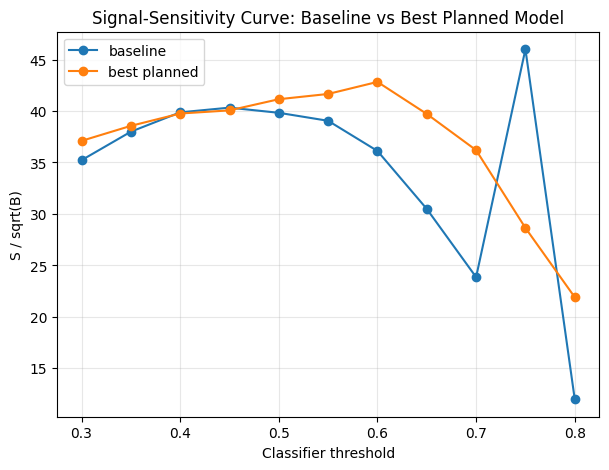

In [71]:
if not planned_results:
    raise RuntimeError("Run the Agentic Planning Loop before running this final comparison cell.")

best_result = max(planned_results, key=lambda result: result["best"]["S_over_sqrt_B"])
best_agent = best_result["agent"]
best_plan = best_result["plan"]
best_scan = best_result["scan"]
best_scores = best_result["scores"]

print("Baseline model:")
print(baseline_classifier.describe())
print(f"Baseline best S/sqrt(B) = {baseline_best['S_over_sqrt_B']:.2f} at threshold {baseline_best['threshold']:.2f}.")
print()

print("Best planned model:")
print(best_agent.describe())
print(
    f"Best planned S/sqrt(B) = {best_result['best']['S_over_sqrt_B']:.2f} "
    f"at threshold {best_result['best']['threshold']:.2f}."
)
print(f"Planning rationale: {best_plan['rationale']}")
print(f"Features used ({len(best_plan['feature_columns'])}): {', '.join(best_plan['feature_columns'])}")
print(f"Hyperparameters: {json.dumps(best_plan['hyperparameters'], sort_keys=True)}")

comparison = pd.DataFrame([
    {
        "model": "baseline",
        "strategy": baseline_classifier.name,
        "model_family": baseline_classifier.strategy["model_family"],
        "features_used": len(baseline_classifier.feature_names_),
        "test_auc": baseline_classifier.metrics["test"]["auc"],
        "best_threshold": baseline_best["threshold"],
        "best_S_over_sqrt_B": baseline_best["S_over_sqrt_B"],
    },
    {
        "model": "best_planned",
        "strategy": best_plan["strategy_name"],
        "model_family": best_plan["model_family"],
        "features_used": len(best_plan["feature_columns"]),
        "test_auc": best_agent.metrics["test"]["auc"],
        "best_threshold": best_result["best"]["threshold"],
        "best_S_over_sqrt_B": best_result["best"]["S_over_sqrt_B"],
    },
])
display(comparison)

baseline_fpr, baseline_tpr, _ = roc_curve(baseline_classifier.y_test, baseline_scores)
best_fpr, best_tpr, _ = roc_curve(best_agent.y_test, best_scores)

plt.figure(figsize=(7, 5))
plt.plot(baseline_fpr, baseline_tpr, label=f"baseline AUC={baseline_classifier.metrics['test']['auc']:.3f}")
plt.plot(best_fpr, best_tpr, label=f"best planned AUC={best_agent.metrics['test']['auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC Comparison: Baseline vs Best Planned Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 5))
plt.plot(baseline_scan["threshold"], baseline_scan["S_over_sqrt_B"], marker="o", label="baseline")
plt.plot(best_scan["threshold"], best_scan["S_over_sqrt_B"], marker="o", label="best planned")
plt.xlabel("Classifier threshold")
plt.ylabel("S / sqrt(B)")
plt.title("Signal-Sensitivity Curve: Baseline vs Best Planned Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Ironically, finding that histgradientboost and other models peaked repeatedly around 42.5, but weird spike on baseline is 46...
# Tried extensively altering the prompt, but haven't been able to get greater than 42.8 significance.
